# Model Development

Probability prediction pipeline with 5-fold stratified cross-validation only.

- **Primary metric:** log loss
- **Secondary metric:** AUC ROC
- **Validation:** out-of-fold CV scores on `train.csv` (competition `test.csv` reserved for submission)
- **Models:** baseline, logistic regression, XGBoost, LightGBM, CatBoost


## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    confusion_matrix,
    mean_squared_error,
    pairwise_distances,
    normalized_mutual_info_score,
    balanced_accuracy_score,
    roc_auc_score,
    log_loss,
    roc_curve,
)
from sklearn.utils.class_weight import compute_sample_weight

import seaborn as sns
import statsmodels.api as sm
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

c:\Users\Nick\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load cleaned and engineered data

In [3]:
def load_data(file):
    df = pd.read_csv(file)
    return df


def engineer_features(df):
    df = df.copy()
    pay_amt_cols = [f"PAY_AMT{i}" for i in range(1, 7)]
    bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
    pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

    df["total_pay"] = df[pay_amt_cols].sum(axis=1)
    df["total_bill"] = df[bill_cols].sum(axis=1)

    for col in bill_cols:
        df[f"credit_util_{col[-1]}"] = df[col] / df["LIMIT_BAL"]

    months = np.arange(1, 7)
    x_centered = months - months.mean()
    bill_values = df[bill_cols].to_numpy()
    df["bill_slope"] = (bill_values * x_centered).sum(axis=1) / (x_centered**2).sum()

    for i in range(1, 6):
        prev_col = f"BILL_AMT{i}"
        next_col = f"BILL_AMT{i + 1}"
        df[f"bill_abs_change_{i}_{i + 1}"] = df[next_col] - df[prev_col]
        df[f"bill_pct_change_{i}_{i + 1}"] = (
            (df[next_col] - df[prev_col]) / df[prev_col].replace(0, np.nan)
        )

    df["bill_abs_change_1_6"] = df["BILL_AMT6"] - df["BILL_AMT1"]
    df["bill_pct_change_1_6"] = (
        (df["BILL_AMT6"] - df["BILL_AMT1"]) / df["BILL_AMT1"].replace(0, np.nan)
    )

    df["max_delay"] = df[pay_cols].max(axis=1)
    df["num_months_delayed"] = (df[pay_cols] > 0).sum(axis=1)
    df["num_severe_delays"] = (df[pay_cols] >= 2).sum(axis=1)
    df["ever_delayed"] = (df[pay_cols] > 0).any(axis=1).astype(int)
    df["mean_pay_status"] = df[pay_cols].mean(axis=1)


    # past here are new feature engineered variables
    df["recent_delay_avg"] = df[["PAY_0", "PAY_2"]].mean(axis=1)
    df["older_delay_avg"] = df[["PAY_4", "PAY_5", "PAY_6"]].mean(axis=1)
    df["delay_deterioration"] = df["recent_delay_avg"] - df["older_delay_avg"]

    delay = df[["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]].clip(lower=0)

    df["weighted_delay"] = (
        6 * delay["PAY_0"] +
        5 * delay["PAY_2"] +
        4 * delay["PAY_3"] +
        3 * delay["PAY_4"] +
        2 * delay["PAY_5"] +
        1 * delay["PAY_6"]
    )

    for i in range(1, 7):
        df[f"pay_bill_ratio_{i}"] = (
            df[f"PAY_AMT{i}"] /
            (df[f"BILL_AMT{i}"].abs() + 100)
        )

    ratio_cols = [f"pay_bill_ratio_{i}" for i in range(1, 7)]

    df["mean_pay_bill_ratio"] = df[ratio_cols].mean(axis=1)
    df["min_pay_bill_ratio"] = df[ratio_cols].min(axis=1)
    df["num_low_pay_ratio"] = (df[ratio_cols] < 0.1).sum(axis=1)
    return df


train_df = engineer_features(load_data("train.csv"))
test_df = engineer_features(load_data("test.csv"))

target_col = "default"
drop_cols = ["client_id", target_col]
all_feature_cols = [col for col in train_df.columns if col not in drop_cols]

y = train_df[target_col]

print(f"train_df: {train_df.shape}")
print(f"test_df: {test_df.shape}")
print(f"all features: {len(all_feature_cols)}")
print(f"target distribution:\n{y.value_counts(normalize=True)}")

train_df: (24000, 64)
test_df: (6000, 63)
all features: 62
target distribution:
default
0    0.778792
1    0.221208
Name: proportion, dtype: float64


## 3. Feature sets

- `all_engineered` — original engineered features (before the new-feature comment in section 2)
- `all_engineered_extended` — original + new delay/pay-bill ratio features
- `selected_major` — Spearman-selected subset

In [4]:
NEW_ENGINEERED_COLS = [
    "recent_delay_avg",
    "older_delay_avg",
    "delay_deterioration",
    "weighted_delay",
    *[f"pay_bill_ratio_{i}" for i in range(1, 7)],
    "mean_pay_bill_ratio",
    "min_pay_bill_ratio",
    "num_low_pay_ratio",
]

original_engineered_cols = [
    col for col in all_feature_cols if col not in NEW_ENGINEERED_COLS
]

FEATURE_SETS = {
    "all_engineered": original_engineered_cols,
    "all_engineered_extended": all_feature_cols,
    "selected_major": [
        "num_severe_delays",
        "num_months_delayed",
        "ever_delayed",
        "max_delay",
        "PAY_0",
        "mean_pay_status",
        "PAY_2",
        "PAY_3",
        "PAY_4",
        "total_pay",
        "LIMIT_BAL",
    ],
}

for name, cols in FEATURE_SETS.items():
    print(f"{name}: {len(cols)} features")
    print(cols)

all_engineered: 49 features
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'total_pay', 'total_bill', 'credit_util_1', 'credit_util_2', 'credit_util_3', 'credit_util_4', 'credit_util_5', 'credit_util_6', 'bill_slope', 'bill_abs_change_1_2', 'bill_pct_change_1_2', 'bill_abs_change_2_3', 'bill_pct_change_2_3', 'bill_abs_change_3_4', 'bill_pct_change_3_4', 'bill_abs_change_4_5', 'bill_pct_change_4_5', 'bill_abs_change_5_6', 'bill_pct_change_5_6', 'bill_abs_change_1_6', 'bill_pct_change_1_6', 'max_delay', 'num_months_delayed', 'num_severe_delays', 'ever_delayed', 'mean_pay_status']
all_engineered_extended: 62 features
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT

## 4. Model pipeline

In [5]:
RANDOM_STATE = 42
CV_FOLDS = 5


def get_models():
    return {
        "baseline": DummyClassifier(strategy="prior"),
        "logistic_regression": Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                (
                    "clf",
                    LogisticRegression(
                        max_iter=1000,
                        C=1.0,
                        solver="lbfgs",
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "xgboost": xgb.XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "lightgbm": lgb.LGBMClassifier(
            objective="binary",
            metric="binary_logloss",
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        ),
        "catboost": CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="Logloss",
            iterations=300,
            depth=4,
            learning_rate=0.05,
            subsample=0.8,
            random_state=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        ),
    }


def run_probability_pipeline(X, y, feature_set_name, plot_roc=True):
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scoring = {"log_loss": "neg_log_loss", "roc_auc": "roc_auc"}

    results = []
    roc_data = {}

    for model_name, model in get_models().items():
        cv_scores = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring=scoring,
            return_train_score=True,
            n_jobs=-1,
        )

        val_log_loss_mean = -cv_scores["test_log_loss"].mean()
        val_roc_auc_mean = cv_scores["test_roc_auc"].mean()

        oof_prob = cross_val_predict(
            model,
            X,
            y,
            cv=cv,
            method="predict_proba",
            n_jobs=-1,
        )[:, 1]

        results.append(
            {
                "feature_set": feature_set_name,
                "model": model_name,
                "train_log_loss_mean": -cv_scores["train_log_loss"].mean(),
                "val_log_loss_mean": val_log_loss_mean,
                "val_log_loss_std": cv_scores["test_log_loss"].std(),
                "train_roc_auc_mean": cv_scores["train_roc_auc"].mean(),
                "val_roc_auc_mean": val_roc_auc_mean,
                "val_roc_auc_std": cv_scores["test_roc_auc"].std(),
            }
        )

        fpr, tpr, _ = roc_curve(y, oof_prob)
        roc_data[model_name] = (fpr, tpr, val_roc_auc_mean)

    results_df = pd.DataFrame(results)

    if plot_roc:
        fig, ax = plt.subplots(figsize=(8, 6))
        for model_name, (fpr, tpr, auc_score) in roc_data.items():
            ax.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.3f})")
        ax.plot([0, 1], [0, 1], "k--", label="random")
        ax.set(xlabel="False positive rate", ylabel="True positive rate")
        ax.set_title(f"ROC curves (OOF CV) — {feature_set_name}")
        ax.legend(loc="lower right")
        plt.tight_layout()
        plt.show()

    return results_df


## 5. Feature set 1 — original all engineered variables

Original engineered features only (excludes variables added after the `# past here are new feature engineered variables` comment in section 2).

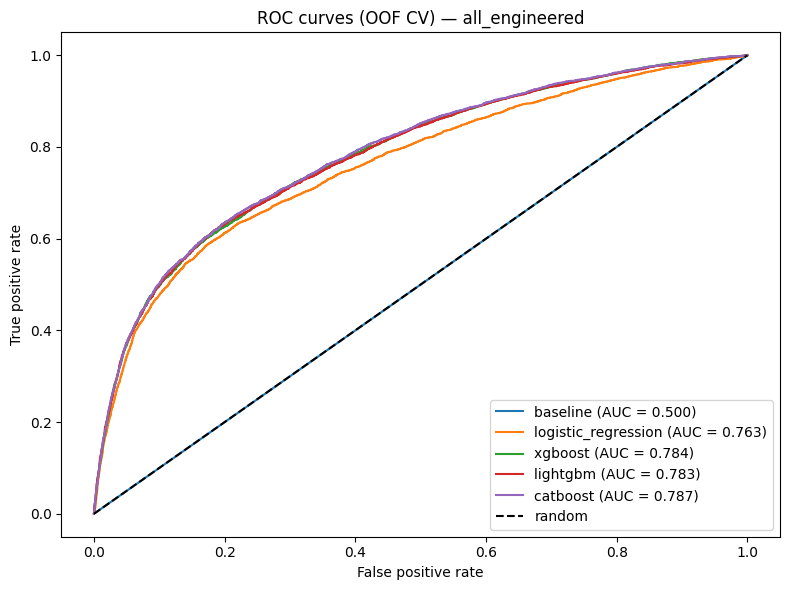

      feature_set                model  train_log_loss_mean  \
0  all_engineered             baseline             0.528433   
1  all_engineered  logistic_regression             0.438460   
2  all_engineered              xgboost             0.368207   
3  all_engineered             lightgbm             0.375234   
4  all_engineered             catboost             0.404262   

   val_log_loss_mean  val_log_loss_std  train_roc_auc_mean  val_roc_auc_mean  \
0           0.528433          0.000105            0.500000          0.500000   
1           0.440933          0.005863            0.766894          0.763389   
2           0.427104          0.006275            0.864230          0.783996   
3           0.427241          0.006618            0.855737          0.783395   
4           0.425119          0.006192            0.815566          0.786777   

   val_roc_auc_std  
0         0.000000  
1         0.010623  
2         0.008967  
3         0.009767  
4         0.009514  


In [6]:
X_all = train_df[FEATURE_SETS["all_engineered"]]
results_all = run_probability_pipeline(X_all, y, "all_engineered")
print(results_all)

## 6. Feature set 2 — all engineered including new variables

All original engineered features plus the new delay and pay/bill ratio variables from section 2.

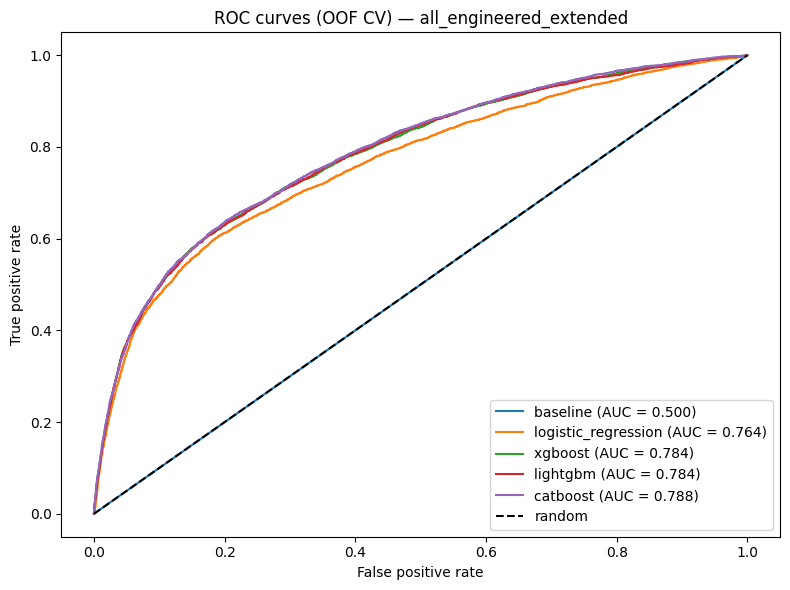

               feature_set                model  train_log_loss_mean  \
0  all_engineered_extended             baseline             0.528433   
1  all_engineered_extended  logistic_regression             0.437590   
2  all_engineered_extended              xgboost             0.364915   
3  all_engineered_extended             lightgbm             0.371866   
4  all_engineered_extended             catboost             0.402795   

   val_log_loss_mean  val_log_loss_std  train_roc_auc_mean  val_roc_auc_mean  \
0           0.528433          0.000105            0.500000          0.500000   
1           0.440804          0.005370            0.768755          0.763984   
2           0.426638          0.006015            0.868977          0.784259   
3           0.427104          0.006749            0.860463          0.783932   
4           0.424442          0.006374            0.818383          0.787599   

   val_roc_auc_std  
0         0.000000  
1         0.009896  
2         0.008692  
3 

In [7]:
X_all_extended = train_df[FEATURE_SETS["all_engineered_extended"]]
results_all_extended = run_probability_pipeline(
    X_all_extended, y, "all_engineered_extended"
)
print(results_all_extended)

## 7. Feature set 3 — selected major variables

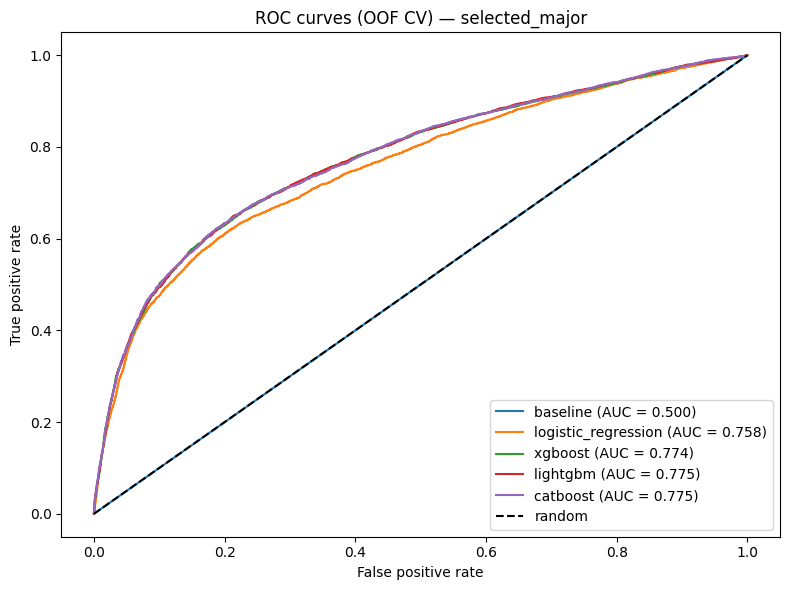

,feature_set,model,train_log_loss_mean,val_log_loss_mean,val_log_loss_std,train_roc_auc_mean,val_roc_auc_mean,val_roc_auc_std
0,selected_major,baseline,0.528433,0.528433,0.000105,0.500000,0.500000,0.000000
1,selected_major,logistic_regression,0.441661,0.442110,0.005919,0.759034,0.758416,0.011440
2,selected_major,xgboost,0.407060,0.431002,0.006107,0.806740,0.774445,0.008775
3,selected_major,lightgbm,0.410079,0.430798,0.006288,0.803568,0.775046,0.009082
4,selected_major,catboost,0.419284,0.429956,0.006010,0.787962,0.775139,0.009430


In [9]:
X_selected = train_df[FEATURE_SETS["selected_major"]]
results_selected = run_probability_pipeline(X_selected, y, "selected_major")
results_selected

## 8. Combined results summary

In [10]:
all_results = pd.concat(
    [results_all, results_all_extended, results_selected], ignore_index=True
)
summary_cols = [
    "feature_set",
    "model",
    "train_log_loss_mean",
    "val_log_loss_mean",
    "val_log_loss_std",
    "train_roc_auc_mean",
    "val_roc_auc_mean",
    "val_roc_auc_std",
]
print(all_results[summary_cols].sort_values(["feature_set", "val_log_loss_mean"]))


                feature_set                model  train_log_loss_mean  \
4            all_engineered             catboost             0.404262   
2            all_engineered              xgboost             0.368207   
3            all_engineered             lightgbm             0.375234   
1            all_engineered  logistic_regression             0.438460   
0            all_engineered             baseline             0.528433   
9   all_engineered_extended             catboost             0.402795   
7   all_engineered_extended              xgboost             0.364915   
8   all_engineered_extended             lightgbm             0.371866   
6   all_engineered_extended  logistic_regression             0.437590   
5   all_engineered_extended             baseline             0.528433   
14           selected_major             catboost             0.419284   
13           selected_major             lightgbm             0.410079   
12           selected_major              xgboost   

## 9. Untuned boosting model prediction correlation

Correlation of out-of-fold predicted probabilities for XGBoost, LightGBM, and CatBoost.

In [11]:
BOOSTING_MODELS = ["xgboost", "lightgbm", "catboost"]


def get_boosting_oof_probs(X, y, model_names=BOOSTING_MODELS):
    cv = StratifiedKFold(
        n_splits=CV_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    models = get_models()

    probs = {}
    for name in model_names:
        probs[name] = cross_val_predict(
            models[name],
            X,
            y,
            cv=cv,
            method="predict_proba",
            n_jobs=-1,
        )[:, 1]

    return pd.DataFrame(probs)


for feature_set_name, X in [
    ("all_engineered", X_all),
    ("all_engineered_extended", X_all_extended),
    ("selected_major", X_selected),
]:
    oof_probs = get_boosting_oof_probs(X, y)

    print(f"\n{feature_set_name} — Pearson correlation")
    print(oof_probs.corr(method="pearson").to_string())

    print(f"\n{feature_set_name} — Spearman correlation")
    print(oof_probs.corr(method="spearman").to_string())



all_engineered — Pearson correlation
           xgboost  lightgbm  catboost
xgboost   1.000000  0.989154  0.983269
lightgbm  0.989154  1.000000  0.982604
catboost  0.983269  0.982604  1.000000

all_engineered — Spearman correlation
           xgboost  lightgbm  catboost
xgboost   1.000000  0.978723  0.968999
lightgbm  0.978723  1.000000  0.966424
catboost  0.968999  0.966424  1.000000

all_engineered_extended — Pearson correlation
           xgboost  lightgbm  catboost
xgboost   1.000000  0.988821  0.982788
lightgbm  0.988821  1.000000  0.983013
catboost  0.982788  0.983013  1.000000

all_engineered_extended — Spearman correlation
           xgboost  lightgbm  catboost
xgboost   1.000000  0.976786  0.966548
lightgbm  0.976786  1.000000  0.966278
catboost  0.966548  0.966278  1.000000

selected_major — Pearson correlation
           xgboost  lightgbm  catboost
xgboost   1.000000  0.994552  0.990211
lightgbm  0.994552  1.000000  0.990845
catboost  0.990211  0.990845  1.000000

selected_

## 10. Optuna boosting tuning setup

Tune XGBoost, LightGBM, and CatBoost hyperparameters and feature combinations using 5-fold stratified CV on the full training set.

- **Optimise:** mean CV log loss (minimise)
- **Tiebreak:** higher CV AUC ROC
- **Storage:** separate SQLite DB (`optuna_boosting_extended.db`) and study names so extended feature presets do not conflict with the original notebook studies
- **Run section 11 manually** when ready


In [14]:
OPTUNA_N_TRIALS = 50
OPTUNA_STORAGE = "sqlite:///optuna_boosting_extended.db"
OPTUNA_BEST_PATH = "optuna_best_extended.json"
BLEND_BEST_PATH = "blend_best_extended.json"
OPTUNA_RANDOM_STATE = RANDOM_STATE
OPTUNA_CV_FOLDS = CV_FOLDS

FEATURE_BLOCKS = {
    "demographics": ["SEX", "EDUCATION", "MARRIAGE", "AGE", "LIMIT_BAL"],
    "delay_engineered": [
        "num_severe_delays",
        "num_months_delayed",
        "ever_delayed",
        "max_delay",
        "mean_pay_status",
    ],
    "pay_status": ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"],
    "pay_amounts": [
        "PAY_AMT1",
        "PAY_AMT2",
        "PAY_AMT3",
        "PAY_AMT4",
        "PAY_AMT5",
        "PAY_AMT6",
        "total_pay",
    ],
    "bill_amounts": [
        "BILL_AMT1",
        "BILL_AMT2",
        "BILL_AMT3",
        "BILL_AMT4",
        "BILL_AMT5",
        "BILL_AMT6",
        "total_bill",
    ],
    "credit_util": [f"credit_util_{i}" for i in range(1, 7)],
    "bill_trends": [
        "bill_slope",
        "bill_abs_change_1_2",
        "bill_pct_change_1_2",
        "bill_abs_change_2_3",
        "bill_pct_change_2_3",
        "bill_abs_change_3_4",
        "bill_pct_change_3_4",
        "bill_abs_change_4_5",
        "bill_pct_change_4_5",
        "bill_abs_change_5_6",
        "bill_pct_change_5_6",
        "bill_abs_change_1_6",
        "bill_pct_change_1_6",
    ],
    "new_engineered": NEW_ENGINEERED_COLS,
}


def select_feature_cols(trial):
    preset = trial.suggest_categorical(
        "feature_preset",
        [
            "all_engineered",
            "all_engineered_extended",
            "selected_major",
            "custom_blocks",
        ],
    )

    if preset == "all_engineered":
        return FEATURE_SETS["all_engineered"], preset

    if preset == "all_engineered_extended":
        return FEATURE_SETS["all_engineered_extended"], preset

    if preset == "selected_major":
        return FEATURE_SETS["selected_major"], preset

    cols = []
    active_blocks = []
    for block_name, block_cols in FEATURE_BLOCKS.items():
        if trial.suggest_int(f"block_{block_name}", 0, 1):
            cols.extend(block_cols)
            active_blocks.append(block_name)

    cols = list(dict.fromkeys(cols))
    if not cols:
        raise optuna.TrialPruned("No feature blocks selected")

    return cols, f"custom_blocks({','.join(active_blocks)})"


def build_xgb_classifier(trial):
    return xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=trial.suggest_int("n_estimators", 100, 500, step=50),
        max_depth=trial.suggest_int("max_depth", 3, 8),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        random_state=OPTUNA_RANDOM_STATE,
        n_jobs=-1,
    )


def build_lgb_classifier(trial):
    return lgb.LGBMClassifier(
        objective="binary",
        metric="binary_logloss",
        n_estimators=trial.suggest_int("n_estimators", 100, 500, step=50),
        max_depth=trial.suggest_int("max_depth", 3, 8),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 100),
        random_state=OPTUNA_RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )


def build_cat_classifier(trial):
    return CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="Logloss",
        iterations=trial.suggest_int("iterations", 100, 500, step=50),
        depth=trial.suggest_int("depth", 3, 8),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 0.1, 10.0, log=True),
        random_state=OPTUNA_RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
    )


def make_boosting_objective(model_name, build_model_fn):
    def objective(trial):
        feature_cols, feature_label = select_feature_cols(trial)
        X = train_df[feature_cols]
        model = build_model_fn(trial)

        cv = StratifiedKFold(
            n_splits=OPTUNA_CV_FOLDS,
            shuffle=True,
            random_state=OPTUNA_RANDOM_STATE,
        )
        cv_scores = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring={"log_loss": "neg_log_loss", "roc_auc": "roc_auc"},
            n_jobs=-1,
        )

        mean_log_loss = -cv_scores["test_log_loss"].mean()
        mean_roc_auc = cv_scores["test_roc_auc"].mean()

        trial.set_user_attr("model", model_name)
        trial.set_user_attr("feature_label", feature_label)
        trial.set_user_attr("n_features", len(feature_cols))
        trial.set_user_attr("feature_cols", feature_cols)
        trial.set_user_attr("val_log_loss_std", cv_scores["test_log_loss"].std())
        trial.set_user_attr("val_roc_auc_mean", mean_roc_auc)

        return mean_log_loss

    return objective


BOOSTING_STUDIES = {
    "xgboost": optuna.create_study(
        study_name="xgb_default_prediction_extended",
        storage=OPTUNA_STORAGE,
        load_if_exists=True,
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=OPTUNA_RANDOM_STATE),
    ),
    "lightgbm": optuna.create_study(
        study_name="lgb_default_prediction_extended",
        storage=OPTUNA_STORAGE,
        load_if_exists=True,
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=OPTUNA_RANDOM_STATE + 1),
    ),
    
    "catboost": optuna.create_study(
        study_name="cat_default_prediction_extended",
        storage=OPTUNA_STORAGE,
        load_if_exists=True,
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=OPTUNA_RANDOM_STATE + 2),
    ),
}

BOOSTING_OBJECTIVES = {
    "xgboost": make_boosting_objective("xgboost", build_xgb_classifier),
    "lightgbm": make_boosting_objective("lightgbm", build_lgb_classifier),
    "catboost": make_boosting_objective("catboost", build_cat_classifier),
}

print("Optuna studies ready:", list(BOOSTING_STUDIES))
print(f"Planned trials per model: {OPTUNA_N_TRIALS}")
print("Run section 11 to start tuning.")


Optuna studies ready: ['xgboost', 'lightgbm', 'catboost']
Planned trials per model: 50
Run section 11 to start tuning.


## 11. Run Optuna search (manual)

Run this cell locally when ready. It is intentionally not executed automatically.


In [15]:
for model_name, study in BOOSTING_STUDIES.items():
    print(f"\nTuning {model_name}...")
    study.optimize(
        BOOSTING_OBJECTIVES[model_name],
        n_trials=OPTUNA_N_TRIALS,
        show_progress_bar=True,
    )



Tuning xgboost...


Best trial: 16. Best value: 0.424062: 100%|██████████| 50/50 [02:55<00:00,  3.51s/it]



Tuning lightgbm...


Best trial: 46. Best value: 0.424447: 100%|██████████| 50/50 [02:52<00:00,  3.45s/it]



Tuning catboost...


Best trial: 28. Best value: 0.423791: 100%|██████████| 50/50 [11:07<00:00, 13.36s/it]


## 12. Rankings and optimum combinations

Sort by CV log loss (ascending), then CV AUC ROC (descending) as tiebreak.


In [16]:
import json

def build_optuna_rankings(study, model_name):
    rows = []
    for trial in study.trials:
        if trial.state != optuna.trial.TrialState.COMPLETE:
            continue

        row = {
            "model": model_name,
            "trial": trial.number,
            "val_log_loss_mean": trial.value,
            "val_log_loss_std": trial.user_attrs.get("val_log_loss_std"),
            "val_roc_auc_mean": trial.user_attrs.get("val_roc_auc_mean"),
            "feature_label": trial.user_attrs.get("feature_label"),
            "n_features": trial.user_attrs.get("n_features"),
        }
        row.update(trial.params)
        rows.append(row)

    rankings = pd.DataFrame(rows)
    if rankings.empty:
        return rankings

    return rankings.sort_values(
        ["val_log_loss_mean", "val_roc_auc_mean"],
        ascending=[True, False],
    ).reset_index(drop=True)


def store_optuna_best(study, rankings, model_name):
    if rankings.empty:
        raise ValueError(f"No completed Optuna trials found for {model_name}. Run section 11 first.")

    best_trial = study.trials[int(rankings.iloc[0]["trial"])]
    param_prefixes = ("feature_", "block_")
    return {
        "model": model_name,
        "trial_number": int(best_trial.number),
        "val_log_loss_mean": float(best_trial.value),
        "val_log_loss_std": float(best_trial.user_attrs["val_log_loss_std"]),
        "val_roc_auc_mean": float(best_trial.user_attrs["val_roc_auc_mean"]),
        "feature_label": best_trial.user_attrs["feature_label"],
        "feature_cols": best_trial.user_attrs["feature_cols"],
        "params": {
            key: best_trial.params[key]
            for key in best_trial.params
            if not key.startswith(param_prefixes)
        },
    }


optuna_rankings = {
    model_name: build_optuna_rankings(study, model_name)
    for model_name, study in BOOSTING_STUDIES.items()
}

for model_name, rankings in optuna_rankings.items():
    print(f"\nTop 10 trials — {model_name}")
    display(rankings.head(10))

OPTUNA_BEST = {}
for model_name, study in BOOSTING_STUDIES.items():
    try:
        OPTUNA_BEST[model_name] = store_optuna_best(
            study,
            optuna_rankings[model_name],
            model_name,
        )
    except ValueError as exc:
        print(exc)

if OPTUNA_BEST:
    with open(OPTUNA_BEST_PATH, "w", encoding="utf-8") as f:
        json.dump(OPTUNA_BEST, f, indent=2)
    print(f"Saved {OPTUNA_BEST_PATH}")

    print("\nOptimum combinations stored in OPTUNA_BEST:")
    for model_name, best in OPTUNA_BEST.items():
        print(
            f"  {model_name}: trial={best['trial_number']}, "
            f"log loss={best['val_log_loss_mean']:.6f}, "
            f"AUC={best['val_roc_auc_mean']:.6f}, "
            f"features={best['feature_label']}"
        )



Top 10 trials — xgboost


,model,trial,val_log_loss_mean,val_log_loss_std,val_roc_auc_mean,feature_label,n_features,feature_preset,n_estimators,max_depth,...,reg_alpha,min_child_weight,block_demographics,block_delay_engineered,block_pay_status,block_pay_amounts,block_bill_amounts,block_credit_util,block_bill_trends,block_new_engineered
0,xgboost,16,0.424062,0.006364,0.788286,all_engineered_extended,62,all_engineered_extended,300,4,...,0.000043,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,xgboost,41,0.424109,0.006478,0.788289,all_engineered_extended,62,all_engineered_extended,300,4,...,0.007596,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,xgboost,14,0.424127,0.006550,0.788169,all_engineered_extended,62,all_engineered_extended,300,4,...,0.001181,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,xgboost,42,0.424136,0.006409,0.788238,all_engineered_extended,62,all_engineered_extended,300,4,...,0.005620,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,xgboost,22,0.424231,0.006594,0.787901,all_engineered_extended,62,all_engineered_extended,250,4,...,0.000099,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,xgboost,21,0.424298,0.006394,0.788123,all_engineered_extended,62,all_engineered_extended,250,5,...,0.000143,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,xgboost,25,0.424342,0.006986,0.787968,all_engineered_extended,62,all_engineered_extended,300,4,...,0.005333,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,xgboost,45,0.424382,0.006434,0.788208,all_engineered_extended,62,all_engineered_extended,350,4,...,0.003387,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,xgboost,17,0.424391,0.006386,0.787986,all_engineered_extended,62,all_engineered_extended,250,5,...,0.000160,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,xgboost,40,0.424450,0.006500,0.787961,all_engineered_extended,62,all_engineered_extended,200,4,...,0.495724,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Top 10 trials — lightgbm


,model,trial,val_log_loss_mean,val_log_loss_std,val_roc_auc_mean,feature_label,n_features,feature_preset,n_estimators,max_depth,...,reg_alpha,min_child_samples,block_demographics,block_delay_engineered,block_pay_status,block_pay_amounts,block_bill_amounts,block_credit_util,block_bill_trends,block_new_engineered
0,lightgbm,46,0.424447,0.006652,0.788048,"custom_blocks(demographics,delay_engineered,pa...",62,custom_blocks,200,4,...,1.812655,67,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,lightgbm,47,0.424545,0.006864,0.788333,"custom_blocks(demographics,delay_engineered,pa...",62,custom_blocks,200,4,...,9.970681,69,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,lightgbm,42,0.424608,0.006368,0.787633,"custom_blocks(demographics,delay_engineered,pa...",62,custom_blocks,150,4,...,0.163114,68,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,lightgbm,34,0.424615,0.006523,0.787895,"custom_blocks(demographics,delay_engineered,pa...",62,custom_blocks,250,4,...,0.004641,100,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,lightgbm,39,0.424698,0.006405,0.787764,"custom_blocks(demographics,delay_engineered,pa...",62,custom_blocks,150,5,...,0.020769,67,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
5,lightgbm,45,0.424731,0.006375,0.787698,"custom_blocks(demographics,delay_engineered,pa...",62,custom_blocks,150,4,...,0.383267,70,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
6,lightgbm,30,0.424880,0.006568,0.787455,all_engineered_extended,62,all_engineered_extended,250,4,...,0.000175,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,lightgbm,41,0.424884,0.006492,0.787170,"custom_blocks(demographics,delay_engineered,pa...",62,custom_blocks,150,5,...,0.198010,93,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
8,lightgbm,27,0.424891,0.006410,0.787340,all_engineered_extended,62,all_engineered_extended,350,4,...,0.006631,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,lightgbm,36,0.425084,0.006716,0.787187,"custom_blocks(demographics,delay_engineered,pa...",62,custom_blocks,250,5,...,0.002168,95,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0



Top 10 trials — catboost


,model,trial,val_log_loss_mean,val_log_loss_std,val_roc_auc_mean,feature_label,n_features,feature_preset,iterations,depth,...,subsample,l2_leaf_reg,block_demographics,block_delay_engineered,block_pay_status,block_pay_amounts,block_bill_amounts,block_credit_util,block_bill_trends,block_new_engineered
0,catboost,28,0.423791,0.006466,0.788575,all_engineered_extended,62,all_engineered_extended,300,6,...,0.676955,3.728322,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,catboost,33,0.423900,0.006573,0.788436,all_engineered_extended,62,all_engineered_extended,200,7,...,0.607063,8.016364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,catboost,44,0.423935,0.006592,0.788398,all_engineered_extended,62,all_engineered_extended,250,6,...,0.652537,8.525212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,catboost,31,0.424079,0.006316,0.788230,all_engineered_extended,62,all_engineered_extended,200,6,...,0.607367,6.623281,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,catboost,34,0.424097,0.006615,0.787647,all_engineered_extended,62,all_engineered_extended,200,6,...,0.600408,6.970656,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,catboost,40,0.424104,0.006632,0.788640,all_engineered_extended,62,all_engineered_extended,250,7,...,0.648576,9.782421,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,catboost,41,0.424120,0.006657,0.788789,all_engineered_extended,62,all_engineered_extended,250,7,...,0.648911,9.577501,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,catboost,30,0.424271,0.006447,0.788151,all_engineered_extended,62,all_engineered_extended,200,6,...,0.616041,7.448621,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,catboost,48,0.424314,0.006288,0.788030,all_engineered_extended,62,all_engineered_extended,250,6,...,0.662357,5.103172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,catboost,32,0.424443,0.006988,0.788196,all_engineered_extended,62,all_engineered_extended,200,7,...,0.600212,7.215178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved optuna_best_extended.json

Optimum combinations stored in OPTUNA_BEST:
  xgboost: trial=16, log loss=0.424062, AUC=0.788286, features=all_engineered_extended
  lightgbm: trial=46, log loss=0.424447, AUC=0.788048, features=custom_blocks(demographics,delay_engineered,pay_status,pay_amounts,bill_amounts,credit_util,bill_trends,new_engineered)
  catboost: trial=28, log loss=0.423791, AUC=0.788575, features=all_engineered_extended


## 13. Generate test submissions

Train each tuned boosting model on the full training set and predict on `test_df`.


In [17]:
from pathlib import Path

MODEL_BUILDERS = {
    "xgboost": lambda params: xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params,
    ),
    "lightgbm": lambda params: lgb.LGBMClassifier(
        objective="binary",
        metric="binary_logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
        **params,
    ),
    "catboost": lambda params: CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="Logloss",
        random_state=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
        **params,
    ),
}


def load_optuna_best():
    if "OPTUNA_BEST" in globals() and OPTUNA_BEST:
        return OPTUNA_BEST

    best_path = Path(globals().get("OPTUNA_BEST_PATH", "optuna_best_extended.json"))
    if best_path.exists():
        with best_path.open(encoding="utf-8") as f:
            return json.load(f)

    raise ValueError(
        "OPTUNA_BEST not found. Run sections 10-12 first, or ensure optuna_best_extended.json exists."
    )


def make_submission(model_name, best_config, train_df, test_df, y):
    feature_cols = best_config["feature_cols"]
    model = MODEL_BUILDERS[model_name](best_config["params"])
    model.fit(train_df[feature_cols], y)
    probs = model.predict_proba(test_df[feature_cols])[:, 1]

    submission = pd.DataFrame(
        {
            "client_id": test_df["client_id"],
            "default_probability": probs,
        }
    )
    output_path = f"submission_{model_name}.csv"
    submission.to_csv(output_path, index=False)
    print(
        f"{model_name}: saved {output_path} "
        f"({len(submission)} rows, mean prob={probs.mean():.6f})"
    )
    return submission


best_configs = load_optuna_best()
submissions = {
    model_name: make_submission(model_name, config, train_df, test_df, y)
    for model_name, config in best_configs.items()
}
submissions["xgboost"].head()


xgboost: saved submission_xgboost.csv (6000 rows, mean prob=0.219065)
lightgbm: saved submission_lightgbm.csv (6000 rows, mean prob=0.219429)
catboost: saved submission_catboost.csv (6000 rows, mean prob=0.218748)


,client_id,default_probability
0,CC_0012A082B7B7,0.133141
1,CC_0012BC27DFB6,0.136906
2,CC_001563B2143D,0.109556
3,CC_001B46930B6F,0.100421
4,CC_001D771E1C9F,0.043511


## 14. Optuna blend weight tuning setup

Tune a convex blend of the three best tuned models using out-of-fold predictions.

- **Weights:** `w_xgb`, `w_lgb`, `w_cat = 1 - w_xgb - w_lgb` (each in `[0, 1]`)
- **Optimise:** mean 5-fold CV log loss
- **Run section 15 manually** when ready


In [18]:
BLEND_N_TRIALS = 50
BLEND_MODELS = ["xgboost", "lightgbm", "catboost"]


def get_tuned_oof_probs(model_name, best_config):
    feature_cols = best_config["feature_cols"]
    model = MODEL_BUILDERS[model_name](best_config["params"])
    cv = StratifiedKFold(
        n_splits=CV_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    return cross_val_predict(
        model,
        train_df[feature_cols],
        y,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]


def mean_cv_log_loss(y_true, y_prob, cv):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    fold_losses = [
        log_loss(y_true[val_idx], y_prob[val_idx])
        for _, val_idx in cv.split(y_true, y_true)
    ]
    return float(np.mean(fold_losses))


def blend_weights_from_params(params):
    w_xgb = params["w_xgb"]
    w_lgb = params["w_lgb"]
    w_cat = 1.0 - w_xgb - w_lgb
    return {
        "xgboost": w_xgb,
        "lightgbm": w_lgb,
        "catboost": w_cat,
    }


def blend_oof_probs(weights, oof_probs):
    return (
        weights["xgboost"] * oof_probs["xgboost"]
        + weights["lightgbm"] * oof_probs["lightgbm"]
        + weights["catboost"] * oof_probs["catboost"]
    )


best_configs = load_optuna_best()
tuned_oof_probs = {
    model_name: get_tuned_oof_probs(model_name, best_configs[model_name])
    for model_name in BLEND_MODELS
}

blend_cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)


def blend_objective(trial):
    w_xgb = trial.suggest_float("w_xgb", 0.0, 1.0)
    w_lgb = trial.suggest_float("w_lgb", 0.0, 1.0)
    w_cat = 1.0 - w_xgb - w_lgb
    if w_cat < 0.0:
        raise optuna.TrialPruned()

    weights = {"xgboost": w_xgb, "lightgbm": w_lgb, "catboost": w_cat}
    blended = blend_oof_probs(weights, tuned_oof_probs)
    return mean_cv_log_loss(y, blended, blend_cv)


blend_study = optuna.create_study(
    study_name="boosting_blend_weights_extended",
    storage=OPTUNA_STORAGE,
    load_if_exists=True,
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)

print("Blend study ready.")
print(f"Planned trials: {BLEND_N_TRIALS}")
print("Run section 15 to start tuning.")


Blend study ready.
Planned trials: 50
Run section 15 to start tuning.


## 15. Run blend Optuna search (manual)

Run this cell locally when ready.


In [19]:
blend_study.optimize(
    blend_objective,
    n_trials=BLEND_N_TRIALS,
    show_progress_bar=True,
)


Best trial: 38. Best value: 0.423461: 100%|██████████| 50/50 [00:03<00:00, 15.52it/s]


## 16. Best blend weights and blended submission

Select the best weight combination by mean CV log loss.


In [20]:
def build_blend_rankings(study):
    rows = []
    for trial in study.trials:
        if trial.state != optuna.trial.TrialState.COMPLETE:
            continue

        weights = blend_weights_from_params(trial.params)
        rows.append(
            {
                "trial": trial.number,
                "val_log_loss_mean": trial.value,
                "w_xgboost": weights["xgboost"],
                "w_lightgbm": weights["lightgbm"],
                "w_catboost": weights["catboost"],
            }
        )

    rankings = pd.DataFrame(rows)
    if rankings.empty:
        return rankings

    return rankings.sort_values("val_log_loss_mean").reset_index(drop=True)


def store_blend_best(study, rankings):
    if rankings.empty:
        raise ValueError("No completed blend trials found. Run section 15 first.")

    best_trial = study.trials[int(rankings.iloc[0]["trial"])]
    weights = blend_weights_from_params(best_trial.params)
    blended_oof = blend_oof_probs(weights, tuned_oof_probs)

    return {
        "trial_number": int(best_trial.number),
        "val_log_loss_mean": float(best_trial.value),
        "val_roc_auc_mean": float(roc_auc_score(y, blended_oof)),
        "weights": weights,
        "params": dict(best_trial.params),
    }


def predict_blend(weights, train_df, test_df, y, best_configs):
    blended_probs = np.zeros(len(test_df))
    for model_name, weight in weights.items():
        if weight <= 0:
            continue
        config = best_configs[model_name]
        model = MODEL_BUILDERS[model_name](config["params"])
        model.fit(train_df[config["feature_cols"]], y)
        blended_probs += weight * model.predict_proba(
            test_df[config["feature_cols"]]
        )[:, 1]
    return blended_probs


blend_rankings = build_blend_rankings(blend_study)
blend_rankings.head(20)

try:
    BLEND_BEST = store_blend_best(blend_study, blend_rankings)
    with open(BLEND_BEST_PATH, "w", encoding="utf-8") as f:
        json.dump(BLEND_BEST, f, indent=2)

    print("Best blend stored in BLEND_BEST:")
    print(f"  trial: {BLEND_BEST['trial_number']}")
    print(f"  val log loss: {BLEND_BEST['val_log_loss_mean']:.6f}")
    print(f"  val AUC ROC:  {BLEND_BEST['val_roc_auc_mean']:.6f}")
    print(f"  weights: {BLEND_BEST['weights']}")

    blend_probs = predict_blend(
        BLEND_BEST["weights"], train_df, test_df, y, best_configs
    )
    submission_blend = pd.DataFrame(
        {
            "client_id": test_df["client_id"],
            "default_probability": blend_probs,
        }
    )
    submission_blend.to_csv("submission_blend.csv", index=False)
    print(
        f"Saved submission_blend.csv "
        f"({len(submission_blend)} rows, mean prob={blend_probs.mean():.6f})"
    )
    submission_blend.head()
except ValueError as exc:
    print(exc)


Best blend stored in BLEND_BEST:
  trial: 38
  val log loss: 0.423461
  val AUC ROC:  0.788908
  weights: {'xgboost': 0.26689550739579787, 'lightgbm': 0.19283186968557245, 'catboost': 0.5402726229186297}
Saved submission_blend.csv (6000 rows, mean prob=0.218964)


## 17. Tuned XGBoost nested cross-calibration

Nested CV ensures the calibrator is fit on **out-of-sample** base-model predictions:

1. **Outer fold:** outer train | outer validation
2. **Inside outer train:** inner CV produces OOF XGBoost probabilities
3. **Fit calibrator:** inner-OOF probabilities → outer-train labels
4. **Fit XGBoost** on the full outer train
5. **Predict** outer validation (raw probabilities)
6. **Apply calibrator** to outer-validation probabilities

Methods compared: raw OOF, Platt, temperature, isotonic, shrinkage (`p' = αp + (1-α)ȳ`).


In [21]:
from scipy.optimize import minimize_scalar
from scipy.special import expit, logit
from sklearn.isotonic import IsotonicRegression

OUTER_CV_FOLDS = CV_FOLDS
INNER_CV_FOLDS = CV_FOLDS


def clip_probs(probs, eps=1e-6):
    return np.clip(probs, eps, 1 - eps)


def apply_temperature(probs, temperature):
    logits = logit(clip_probs(probs))
    return expit(logits / temperature)


def apply_shrinkage(probs, alpha, base_rate):
    return alpha * probs + (1 - alpha) * base_rate


def fit_platt(oof_probs, y_train):
    train_logits = logit(clip_probs(oof_probs)).reshape(-1, 1)
    calibrator = LogisticRegression(max_iter=1000)
    calibrator.fit(train_logits, y_train)
    return calibrator


def predict_platt(calibrator, probs):
    val_logits = logit(clip_probs(probs)).reshape(-1, 1)
    return calibrator.predict_proba(val_logits)[:, 1]


def fit_temperature(oof_probs, y_train):
    def nll(temperature):
        if temperature <= 0:
            return np.inf
        calibrated = apply_temperature(oof_probs, temperature)
        return log_loss(y_train, clip_probs(calibrated))

    result = minimize_scalar(nll, bounds=(0.05, 10.0), method="bounded")
    return float(result.x)


def fit_shrinkage_alpha(oof_probs, y_train):
    base_rate = float(np.mean(y_train))

    def nll(alpha):
        if alpha < 0 or alpha > 1:
            return np.inf
        calibrated = apply_shrinkage(oof_probs, alpha, base_rate)
        return log_loss(y_train, clip_probs(calibrated))

    result = minimize_scalar(nll, bounds=(0.0, 1.0), method="bounded")
    return float(result.x), base_rate


def get_inner_oof_probs(X_outer_train, y_outer_train, model, inner_cv):
    inner_oof = np.zeros(len(y_outer_train))

    for inner_train_idx, inner_val_idx in inner_cv.split(X_outer_train, y_outer_train):
        fold_model = clone(model)
        fold_model.fit(
            X_outer_train.iloc[inner_train_idx],
            y_outer_train.iloc[inner_train_idx],
        )
        inner_oof[inner_val_idx] = fold_model.predict_proba(
            X_outer_train.iloc[inner_val_idx]
        )[:, 1]

    return clip_probs(inner_oof)


def fit_calibrator(method, inner_oof_probs, y_outer_train):
    if method == "raw_oof":
        return None

    if method == "platt":
        return fit_platt(inner_oof_probs, y_outer_train)

    if method == "temperature":
        return fit_temperature(inner_oof_probs, y_outer_train)

    if method == "isotonic":
        calibrator = IsotonicRegression(out_of_bounds="clip")
        calibrator.fit(inner_oof_probs, y_outer_train)
        return calibrator

    if method == "shrinkage":
        return fit_shrinkage_alpha(inner_oof_probs, y_outer_train)

    raise ValueError(f"Unknown calibration method: {method}")


def apply_calibrator(method, calibrator, probs):
    if method == "raw_oof":
        return clip_probs(probs)

    if method == "platt":
        return clip_probs(predict_platt(calibrator, probs))

    if method == "temperature":
        return clip_probs(apply_temperature(probs, calibrator))

    if method == "isotonic":
        return clip_probs(calibrator.predict(probs))

    if method == "shrinkage":
        alpha, base_rate = calibrator
        return clip_probs(apply_shrinkage(probs, alpha, base_rate))

    raise ValueError(f"Unknown calibration method: {method}")


def calibrator_summary(method, calibrator):
    if method == "raw_oof":
        return {}

    if method == "platt":
        return {
            "intercept": float(calibrator.intercept_[0]),
            "coef": float(calibrator.coef_[0, 0]),
        }

    if method == "temperature":
        return {"temperature": float(calibrator)}

    if method == "isotonic":
        return {"n_knots": len(calibrator.X_thresholds_)}

    if method == "shrinkage":
        alpha, base_rate = calibrator
        return {"alpha": float(alpha), "base_rate": float(base_rate)}

    raise ValueError(f"Unknown calibration method: {method}")


def nested_cross_calibrate_xgb_oof(X, y, model, method, outer_cv, inner_cv):
    oof_probs = np.zeros(len(y))
    fold_params = []

    for outer_train_idx, outer_val_idx in outer_cv.split(X, y):
        X_outer_train = X.iloc[outer_train_idx]
        y_outer_train = y.iloc[outer_train_idx]
        X_outer_val = X.iloc[outer_val_idx]

        inner_oof = get_inner_oof_probs(X_outer_train, y_outer_train, model, inner_cv)
        calibrator = fit_calibrator(method, inner_oof, y_outer_train)

        outer_model = clone(model)
        outer_model.fit(X_outer_train, y_outer_train)
        outer_val_raw = outer_model.predict_proba(X_outer_val)[:, 1]
        outer_val_cal = apply_calibrator(method, calibrator, outer_val_raw)

        oof_probs[outer_val_idx] = outer_val_cal
        fold_params.append(calibrator_summary(method, calibrator))

    return oof_probs, fold_params


def evaluate_calibration(name, oof_probs, y_true, cv):
    y_values = np.asarray(y_true)
    fold_log_loss = [
        log_loss(y_values[val_idx], oof_probs[val_idx])
        for _, val_idx in cv.split(y_values, y_values)
    ]
    fold_roc_auc = [
        roc_auc_score(y_values[val_idx], oof_probs[val_idx])
        for _, val_idx in cv.split(y_values, y_values)
    ]
    return {
        "method": name,
        "val_log_loss_mean": float(np.mean(fold_log_loss)),
        "val_log_loss_std": float(np.std(fold_log_loss)),
        "val_roc_auc_mean": float(np.mean(fold_roc_auc)),
        "val_roc_auc_std": float(np.std(fold_roc_auc)),
        "mean_pred": float(np.mean(oof_probs)),
        "base_rate": float(np.mean(y_true)),
    }


xgb_best = load_optuna_best()["xgboost"]
xgb_feature_cols = xgb_best["feature_cols"]
X_xgb = train_df[xgb_feature_cols]
tuned_xgb = MODEL_BUILDERS["xgboost"](xgb_best["params"])

outer_cv = StratifiedKFold(
    n_splits=OUTER_CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
inner_cv = StratifiedKFold(
    n_splits=INNER_CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE + 1,
)

calibration_methods = [
    "raw_oof",
    "platt",
    "temperature",
    "isotonic",
    "shrinkage",
]

calibration_results = []
calibration_oof = {}
calibration_fold_params = {}

for method in calibration_methods:
    oof_probs, fold_params = nested_cross_calibrate_xgb_oof(
        X_xgb,
        y,
        tuned_xgb,
        method,
        outer_cv,
        inner_cv,
    )
    calibration_oof[method] = oof_probs
    calibration_fold_params[method] = fold_params

    result = evaluate_calibration(method, oof_probs, y, outer_cv)

    if method == "temperature":
        result["mean_temperature"] = float(np.mean([p["temperature"] for p in fold_params]))
        result["temperature_gt_1"] = result["mean_temperature"] > 1.0
    if method == "shrinkage":
        alphas = [p["alpha"] for p in fold_params]
        result["mean_alpha"] = float(np.mean(alphas))
        result["alpha_lt_1"] = result["mean_alpha"] < 1.0

    calibration_results.append(result)

calibration_report = pd.DataFrame(calibration_results).sort_values("val_log_loss_mean")
print("Nested tuned XGBoost calibration comparison (lower log loss is better):")
print(calibration_report.to_string(index=False))

raw_log_loss = calibration_report.loc[
    calibration_report["method"] == "raw_oof", "val_log_loss_mean"
].iloc[0]
print(f"\nRaw outer-validation log loss baseline: {raw_log_loss:.6f}")

shrinkage_row = calibration_report.loc[calibration_report["method"] == "shrinkage"].iloc[0]
print(
    f"Shrinkage mean alpha: {shrinkage_row['mean_alpha']:.4f} "
    f"({'suggests overconfidence' if shrinkage_row['alpha_lt_1'] else 'does not suggest overconfidence'})"
)

temp_row = calibration_report.loc[calibration_report["method"] == "temperature"].iloc[0]
print(
    f"Temperature mean T: {temp_row['mean_temperature']:.4f} "
    f"({'softens probabilities' if temp_row['temperature_gt_1'] else 'sharpens probabilities'})"
)

XGB_CALIBRATION_BEST = calibration_report.iloc[0].to_dict()
print(f"\nBest calibration method: {XGB_CALIBRATION_BEST['method']}")
calibration_report


Nested tuned XGBoost calibration comparison (lower log loss is better):
     method  val_log_loss_mean  val_log_loss_std  val_roc_auc_mean  val_roc_auc_std  mean_pred  base_rate  mean_temperature temperature_gt_1  mean_alpha alpha_lt_1
    raw_oof           0.423886          0.006532          0.788477         0.009931   0.220864   0.221208               NaN              NaN         NaN        NaN
  shrinkage           0.423891          0.006530          0.788477         0.009931   0.220865   0.221208               NaN              NaN    0.998956       True
temperature           0.423892          0.006526          0.788477         0.009931   0.220907   0.221208          1.000299             True         NaN        NaN
      platt           0.423894          0.006525          0.788477         0.009931   0.221160   0.221208               NaN              NaN         NaN        NaN
   isotonic           0.425480          0.007443          0.787629         0.009951   0.221262   0.221208   

,method,val_log_loss_mean,val_log_loss_std,val_roc_auc_mean,val_roc_auc_std,mean_pred,base_rate,mean_temperature,temperature_gt_1,mean_alpha,alpha_lt_1
0,raw_oof,0.423886,0.006532,0.788477,0.009931,0.220864,0.221208,NaN,NaN,NaN,NaN
4,shrinkage,0.423891,0.006530,0.788477,0.009931,0.220865,0.221208,NaN,NaN,0.998956,True
2,temperature,0.423892,0.006526,0.788477,0.009931,0.220907,0.221208,1.000299,True,NaN,NaN
1,platt,0.423894,0.006525,0.788477,0.009931,0.221160,0.221208,NaN,NaN,NaN,NaN
3,isotonic,0.425480,0.007443,0.787629,0.009951,0.221262,0.221208,NaN,NaN,NaN,NaN


## 18. Tuned XGBoost seed stability

Evaluate tuned XGBoost with the default single seed vs an average over 20 seeds.

Reports mean train/val log loss and AUC from 5-fold CV.


In [22]:
SEED_AVG_N = 20
SEED_AVG_START = RANDOM_STATE


def evaluate_tuned_xgb_seed(X, y, params, seed, cv):
    model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=seed,
        n_jobs=-1,
        **params,
    )
    cv_scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={"log_loss": "neg_log_loss", "roc_auc": "roc_auc"},
        return_train_score=True,
        n_jobs=-1,
    )
    return {
        "seed": seed,
        "train_log_loss_mean": -cv_scores["train_log_loss"].mean(),
        "val_log_loss_mean": -cv_scores["test_log_loss"].mean(),
        "train_roc_auc_mean": cv_scores["train_roc_auc"].mean(),
        "val_roc_auc_mean": cv_scores["test_roc_auc"].mean(),
    }


xgb_best = load_optuna_best()["xgboost"]
X_xgb = train_df[xgb_best["feature_cols"]]
xgb_params = xgb_best["params"]

seed_cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

default_seed_result = evaluate_tuned_xgb_seed(
    X_xgb, y, xgb_params, RANDOM_STATE, seed_cv
)

seed_results = pd.DataFrame(
    [
        evaluate_tuned_xgb_seed(
            X_xgb,
            y,
            xgb_params,
            seed,
            seed_cv,
        )
        for seed in range(SEED_AVG_START, SEED_AVG_START + SEED_AVG_N)
    ]
)

metric_cols = [
    "train_log_loss_mean",
    "val_log_loss_mean",
    "train_roc_auc_mean",
    "val_roc_auc_mean",
]

seed_avg = seed_results[metric_cols].mean()
seed_std = seed_results[metric_cols].std()

comparison_rows = [
    {"run": f"default (seed {RANDOM_STATE})", **default_seed_result},
    {
        "run": f"seed average ({SEED_AVG_N} seeds)",
        **{col: seed_avg[col] for col in metric_cols},
    },
    {
        "run": f"seed std ({SEED_AVG_N} seeds)",
        **{col: seed_std[col] for col in metric_cols},
    },
]

xgb_seed_comparison = pd.DataFrame(comparison_rows)[["run"] + metric_cols]

print("Tuned XGBoost: default seed vs seed-averaged CV metrics")
print(xgb_seed_comparison.to_string(index=False))

print("\nPer-seed results:")
print(seed_results.to_string(index=False))

delta = seed_avg - pd.Series(default_seed_result)[metric_cols]
print("\nSeed average minus default (negative log loss delta = seed avg better):")
print(delta.to_string())

xgb_seed_comparison


Tuned XGBoost: default seed vs seed-averaged CV metrics
                    run  train_log_loss_mean  val_log_loss_mean  train_roc_auc_mean  val_roc_auc_mean
      default (seed 42)             0.396733           0.424062            0.828348          0.788286
seed average (20 seeds)             0.396697           0.424214            0.828372          0.788201
    seed std (20 seeds)             0.000101           0.000142            0.000141          0.000223

Per-seed results:
 seed  train_log_loss_mean  val_log_loss_mean  train_roc_auc_mean  val_roc_auc_mean
   42             0.396733           0.424062            0.828348          0.788286
   43             0.396654           0.424354            0.828412          0.787967
   44             0.396603           0.424348            0.828689          0.788210
   45             0.396860           0.424310            0.828305          0.788110
   46             0.396673           0.424176            0.828163          0.788367
   47        

,run,train_log_loss_mean,val_log_loss_mean,train_roc_auc_mean,val_roc_auc_mean
0,default (seed 42),0.396733,0.424062,0.828348,0.788286
1,seed average (20 seeds),0.396697,0.424214,0.828372,0.788201
2,seed std (20 seeds),0.000101,0.000142,0.000141,0.000223


## 19. Stacked ensemble (OOF meta-learner)

Stack tuned XGBoost, LightGBM, and CatBoost using out-of-fold predicted probabilities as meta-features.

- Base models: Optuna-tuned models from `OPTUNA_BEST`
- Meta-learner: L2-regularized logistic regression
- Hyperparameter search: `C ∈ {0.01, 0.03, 0.1, 0.3, 1, 3}` selected by mean CV log loss
- Leakage control: stacker trained/evaluated only on OOF base-model predictions


In [66]:
import json
from pathlib import Path

STACK_BASE_MODELS = ["xgboost", "lightgbm", "catboost"]
STACKER_C_GRID = [0.01, 0.03, 0.1, 0.3, 1, 3]


def get_tuned_oof_probs_stacking(model_name, best_config):
    feature_cols = best_config["feature_cols"]
    model = MODEL_BUILDERS[model_name](best_config["params"])
    cv = StratifiedKFold(
        n_splits=CV_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    return cross_val_predict(
        model,
        train_df[feature_cols],
        y,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]


def oof_metrics(y_true, oof_probs, cv):
    y_values = np.asarray(y_true)
    fold_log_loss = [
        log_loss(y_values[val_idx], oof_probs[val_idx])
        for _, val_idx in cv.split(y_values, y_values)
    ]
    fold_roc_auc = [
        roc_auc_score(y_values[val_idx], oof_probs[val_idx])
        for _, val_idx in cv.split(y_values, y_values)
    ]
    return {
        "val_log_loss_mean": float(np.mean(fold_log_loss)),
        "val_log_loss_std": float(np.std(fold_log_loss)),
        "val_roc_auc_mean": float(np.mean(fold_roc_auc)),
        "val_roc_auc_std": float(np.std(fold_roc_auc)),
    }


def load_blend_best():
    if "BLEND_BEST" in globals() and BLEND_BEST:
        return BLEND_BEST

    blend_path = Path(globals().get("BLEND_BEST_PATH", "blend_best_extended.json"))
    if blend_path.exists():
        with blend_path.open(encoding="utf-8") as f:
            return json.load(f)

    return None


best_configs = load_optuna_best()
stack_cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

base_oof = {
    model_name: get_tuned_oof_probs_stacking(model_name, best_configs[model_name])
    for model_name in STACK_BASE_MODELS
}

X_meta = pd.DataFrame(base_oof)
X_meta.columns = [f"{name}_oof" for name in STACK_BASE_MODELS]

stacker_cv_results = []
for C in STACKER_C_GRID:
    stacker = LogisticRegression(
        C=C,
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        random_state=RANDOM_STATE,
    )
    cv_scores = cross_validate(
        stacker,
        X_meta,
        y,
        cv=stack_cv,
        scoring={"log_loss": "neg_log_loss", "roc_auc": "roc_auc"},
        n_jobs=-1,
    )
    stacker_cv_results.append(
        {
            "C": C,
            "val_log_loss_mean": -cv_scores["test_log_loss"].mean(),
            "val_log_loss_std": cv_scores["test_log_loss"].std(),
            "val_roc_auc_mean": cv_scores["test_roc_auc"].mean(),
            "val_roc_auc_std": cv_scores["test_roc_auc"].std(),
        }
    )

stacker_cv_report = pd.DataFrame(stacker_cv_results).sort_values("val_log_loss_mean")
best_stacker_row = stacker_cv_report.iloc[0]
STACKER_BEST_C = float(best_stacker_row["C"])

best_stacker = LogisticRegression(
    C=STACKER_BEST_C,
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    random_state=RANDOM_STATE,
)
stacked_oof = cross_val_predict(
    best_stacker,
    X_meta,
    y,
    cv=stack_cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

best_stacker.fit(X_meta, y)
stacker_coefs = pd.Series(
    best_stacker.coef_[0],
    index=X_meta.columns,
)
stacker_intercept = float(best_stacker.intercept_[0])

single_model_rows = []
for model_name in STACK_BASE_MODELS:
    metrics = oof_metrics(y, base_oof[model_name], stack_cv)
    single_model_rows.append({"model": model_name, **metrics})

single_model_report = pd.DataFrame(single_model_rows).sort_values("val_log_loss_mean")
best_single = single_model_report.iloc[0]

comparison_rows = [
    {
        "approach": f"best single ({best_single['model']})",
        "val_log_loss_mean": best_single["val_log_loss_mean"],
        "val_roc_auc_mean": best_single["val_roc_auc_mean"],
    },
    {
        "approach": "stacked logistic (OOF meta-learner)",
        "val_log_loss_mean": oof_metrics(y, stacked_oof, stack_cv)["val_log_loss_mean"],
        "val_roc_auc_mean": oof_metrics(y, stacked_oof, stack_cv)["val_roc_auc_mean"],
    },
]

blend_best = load_blend_best()
if blend_best is not None:
    blend_weights = blend_best["weights"]
    blended_oof = (
        blend_weights["xgboost"] * base_oof["xgboost"]
        + blend_weights["lightgbm"] * base_oof["lightgbm"]
        + blend_weights["catboost"] * base_oof["catboost"]
    )
    blend_metrics = oof_metrics(y, blended_oof, stack_cv)
    comparison_rows.insert(
        1,
        {
            "approach": "weighted blend",
            "val_log_loss_mean": blend_metrics["val_log_loss_mean"],
            "val_roc_auc_mean": blend_metrics["val_roc_auc_mean"],
        },
    )
else:
    print(f"Note: weighted blend comparison skipped (run section 16 or create {BLEND_BEST_PATH}).")

stack_comparison = pd.DataFrame(comparison_rows).sort_values("val_log_loss_mean")

print("Stacker C search (selected by mean CV log loss):")
print(stacker_cv_report.to_string(index=False))
print(f"\nBest stacker C: {STACKER_BEST_C}")
print(f"Stacker intercept: {stacker_intercept:.6f}")
print("\nStacker coefficients (fit on full OOF meta-features):")
print(stacker_coefs.to_string())
print("\nOOF comparison vs best single model and weighted blend:")
print(stack_comparison.to_string(index=False))

STACKER_BEST = {
    "C": STACKER_BEST_C,
    "intercept": stacker_intercept,
    "coefficients": stacker_coefs.to_dict(),
    "val_log_loss_mean": float(
        oof_metrics(y, stacked_oof, stack_cv)["val_log_loss_mean"]
    ),
    "val_roc_auc_mean": float(
        oof_metrics(y, stacked_oof, stack_cv)["val_roc_auc_mean"]
    ),
}

stacker_cv_report
stack_comparison


c:\Users\Nick\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Stacker C search (selected by mean CV log loss):
   C  val_log_loss_mean  val_log_loss_std  val_roc_auc_mean  val_roc_auc_std
3.00           0.427358          0.006209          0.788170         0.009975
1.00           0.427359          0.006195          0.788170         0.009975
0.30           0.427362          0.006154          0.788170         0.009975
0.10           0.427419          0.006021          0.788169         0.009975
0.03           0.428006          0.005611          0.788169         0.009975
0.01           0.431448          0.004751          0.788169         0.009976

Best stacker C: 3.0
Stacker intercept: -2.659784

Stacker coefficients (fit on full OOF meta-features):
xgboost_oof     1.760905
lightgbm_oof    1.788087
catboost_oof    1.824493

OOF comparison vs best single model and weighted blend:
                           approach  val_log_loss_mean  val_roc_auc_mean
                     weighted blend           0.423891          0.788282
             best single (cat

,approach,val_log_loss_mean,val_roc_auc_mean
1,weighted blend,0.423891,0.788282
0,best single (catboost),0.424198,0.787870
2,stacked logistic (OOF meta-learner),0.427358,0.788170


## 20. Logistic regression: scaled L2 vs unscaled

Compare L2-regularized logistic regression with `StandardScaler` across
`C ∈ {0.01, 0.1, 1, 10}` against an unscaled logistic regression baseline.

Uses all engineered features and the same 5-fold stratified CV metric setup.


In [68]:
LOGREG_C_GRID = [0.01, 0.1, 1, 10]


def evaluate_logreg_model(model, X, y, cv, label):
    cv_scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={"log_loss": "neg_log_loss", "roc_auc": "roc_auc"},
        return_train_score=True,
        n_jobs=-1,
    )
    return {
        "model": label,
        "train_log_loss_mean": -cv_scores["train_log_loss"].mean(),
        "val_log_loss_mean": -cv_scores["test_log_loss"].mean(),
        "train_roc_auc_mean": cv_scores["train_roc_auc"].mean(),
        "val_roc_auc_mean": cv_scores["test_roc_auc"].mean(),
    }


logreg_cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

X_logreg = train_df[FEATURE_SETS["all_engineered"]]

logreg_results = []

for C in LOGREG_C_GRID:
    scaled_model = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    C=C,
                    penalty="l2",
                    max_iter=1000,
                    solver="lbfgs",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    logreg_results.append(
        evaluate_logreg_model(
            scaled_model,
            X_logreg,
            y,
            logreg_cv,
            label=f"scaled L2 (C={C})",
        )
    )

unscaled_model = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        (
            "clf",
            LogisticRegression(
                penalty="l2",
                class_weight="balanced",
                max_iter=1000,
                solver="lbfgs",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
logreg_results.append(
    evaluate_logreg_model(
        unscaled_model,
        X_logreg,
        y,
        logreg_cv,
        label="unscaled (C=1.0)",
    )
)

logreg_comparison = pd.DataFrame(logreg_results).sort_values("val_log_loss_mean")

print("Logistic regression comparison (lower val log loss is better):")
print(logreg_comparison.to_string(index=False))

best_scaled = logreg_comparison[
    logreg_comparison["model"].str.startswith("scaled")
].iloc[0]
unscaled_row = logreg_comparison[
    logreg_comparison["model"] == "unscaled (C=1.0)"
].iloc[0]

print(f"\nBest scaled model: {best_scaled['model']}")
print(
    f"  val log loss: {best_scaled['val_log_loss_mean']:.6f}, "
    f"val AUC: {best_scaled['val_roc_auc_mean']:.6f}"
)
print(
    f"Unscaled baseline val log loss: {unscaled_row['val_log_loss_mean']:.6f}, "
    f"val AUC: {unscaled_row['val_roc_auc_mean']:.6f}"
)

LOGREG_BEST_C = float(best_scaled["model"].split("C=")[1].rstrip(")"))
LOGREG_BEST = {
    "C": LOGREG_BEST_C,
    "model_label": best_scaled["model"],
    "val_log_loss_mean": float(best_scaled["val_log_loss_mean"]),
    "val_roc_auc_mean": float(best_scaled["val_roc_auc_mean"]),
}

logreg_comparison


Logistic regression comparison (lower val log loss is better):
             model  train_log_loss_mean  val_log_loss_mean  train_roc_auc_mean  val_roc_auc_mean
 scaled L2 (C=0.1)             0.438519           0.440920            0.766772          0.763271
   scaled L2 (C=1)             0.438460           0.440933            0.766894          0.763389
  scaled L2 (C=10)             0.438459           0.440935            0.766916          0.763383
scaled L2 (C=0.01)             0.439698           0.441718            0.764661          0.761595
  unscaled (C=1.0)             0.648275           0.651506            0.661332          0.659711

Best scaled model: scaled L2 (C=0.1)
  val log loss: 0.440920, val AUC: 0.763271
Unscaled baseline val log loss: 0.651506, val AUC: 0.659711


,model,train_log_loss_mean,val_log_loss_mean,train_roc_auc_mean,val_roc_auc_mean
1,scaled L2 (C=0.1),0.438519,0.440920,0.766772,0.763271
2,scaled L2 (C=1),0.438460,0.440933,0.766894,0.763389
3,scaled L2 (C=10),0.438459,0.440935,0.766916,0.763383
0,scaled L2 (C=0.01),0.439698,0.441718,0.764661,0.761595
4,unscaled (C=1.0),0.648275,0.651506,0.661332,0.659711


## 21. Tuned boosting vs best L2 logistic correlation

Pearson and Spearman correlation of out-of-fold predicted probabilities for the three Optuna-tuned boosting models and the best scaled L2 logistic regression model (`C=0.1` from section 20).

In [69]:
def get_best_logreg_oof_probs(C, feature_cols):
    model = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    C=C,
                    penalty="l2",
                    max_iter=1000,
                    solver="lbfgs",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    cv = StratifiedKFold(
        n_splits=CV_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    return cross_val_predict(
        model,
        train_df[feature_cols],
        y,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]


if "LOGREG_BEST" not in globals():
    if "logreg_comparison" in globals():
        best_scaled_row = logreg_comparison[
            logreg_comparison["model"].str.startswith("scaled")
        ].iloc[0]
        LOGREG_BEST_C = float(best_scaled_row["model"].split("C=")[1].rstrip(")"))
    else:
        LOGREG_BEST_C = 0.1

logreg_feature_cols = FEATURE_SETS["all_engineered"]
best_configs = load_optuna_best()

tuned_logreg_oof = {
    "xgboost": get_tuned_oof_probs("xgboost", best_configs["xgboost"]),
    "lightgbm": get_tuned_oof_probs("lightgbm", best_configs["lightgbm"]),
    "catboost": get_tuned_oof_probs("catboost", best_configs["catboost"]),
    f"logreg_l2_C={LOGREG_BEST_C}": get_best_logreg_oof_probs(
        LOGREG_BEST_C, logreg_feature_cols
    ),
}

oof_corr_df = pd.DataFrame(tuned_logreg_oof)

print(f"Best scaled L2 logistic: C={LOGREG_BEST_C}")
print("\nPearson correlation (OOF probabilities)")
print(oof_corr_df.corr(method="pearson").to_string())
print("\nSpearman correlation (OOF probabilities)")
print(oof_corr_df.corr(method="spearman").to_string())

print("\nLogistic vs boosting (Pearson / Spearman):")
for model_name in ["xgboost", "lightgbm", "catboost"]:
    pearson = oof_corr_df[f"logreg_l2_C={LOGREG_BEST_C}"].corr(
        oof_corr_df[model_name], method="pearson"
    )
    spearman = oof_corr_df[f"logreg_l2_C={LOGREG_BEST_C}"].corr(
        oof_corr_df[model_name], method="spearman"
    )
    print(f"  {model_name}: {pearson:.6f} / {spearman:.6f}")

oof_corr_df.corr(method="pearson")

Best scaled L2 logistic: C=0.1

Pearson correlation (OOF probabilities)
                  xgboost  lightgbm  catboost  logreg_l2_C=0.1
xgboost          1.000000  0.995010  0.991803         0.927615
lightgbm         0.995010  1.000000  0.990562         0.930893
catboost         0.991803  0.990562  1.000000         0.933611
logreg_l2_C=0.1  0.927615  0.930893  0.933611         1.000000

Spearman correlation (OOF probabilities)
                  xgboost  lightgbm  catboost  logreg_l2_C=0.1
xgboost          1.000000  0.990737  0.986347         0.856758
lightgbm         0.990737  1.000000  0.982798         0.861165
catboost         0.986347  0.982798  1.000000         0.868541
logreg_l2_C=0.1  0.856758  0.861165  0.868541         1.000000

Logistic vs boosting (Pearson / Spearman):
  xgboost: 0.927615 / 0.856758
  lightgbm: 0.930893 / 0.861165
  catboost: 0.933611 / 0.868541


,xgboost,lightgbm,catboost,logreg_l2_C=0.1
xgboost,1.000000,0.995010,0.991803,0.927615
lightgbm,0.995010,1.000000,0.990562,0.930893
catboost,0.991803,0.990562,1.000000,0.933611
logreg_l2_C=0.1,0.927615,0.930893,0.933611,1.000000


## 22. XGBoost + best L2 logistic blend (heavy XGB weighting)

Convex blend of Optuna-tuned XGBoost and best scaled L2 logistic (`C=0.1`). Same 5-fold stratified CV with fold-wise train/val log loss and AUC ROC.

In [70]:
XGB_LOGREG_BLEND_WEIGHTS = [
    (1.00, 0.00),
    (0.99, 0.01),
    (0.975, 0.025),
    (0.95, 0.05),
    (0.925, 0.075),
    (0.90, 0.10),
    (0.85, 0.15),
]


def build_best_logreg_pipeline(C):
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    C=C,
                    penalty="l2",
                    max_iter=1000,
                    solver="lbfgs",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def evaluate_xgb_logreg_blend_cv(
    xgb_model,
    logreg_model,
    X_xgb,
    X_logreg,
    y,
    cv,
    w_xgb,
    w_logreg,
):
    y_values = np.asarray(y)
    train_log_loss = []
    val_log_loss = []
    train_roc_auc = []
    val_roc_auc = []

    for train_idx, val_idx in cv.split(X_xgb, y_values):
        y_train = y_values[train_idx]
        y_val = y_values[val_idx]

        xgb_fold = clone(xgb_model)
        logreg_fold = clone(logreg_model)

        xgb_fold.fit(X_xgb.iloc[train_idx], y_train)
        logreg_fold.fit(X_logreg.iloc[train_idx], y_train)

        train_blend = (
            w_xgb * xgb_fold.predict_proba(X_xgb.iloc[train_idx])[:, 1]
            + w_logreg * logreg_fold.predict_proba(X_logreg.iloc[train_idx])[:, 1]
        )
        val_blend = (
            w_xgb * xgb_fold.predict_proba(X_xgb.iloc[val_idx])[:, 1]
            + w_logreg * logreg_fold.predict_proba(X_logreg.iloc[val_idx])[:, 1]
        )

        train_log_loss.append(log_loss(y_train, train_blend))
        val_log_loss.append(log_loss(y_val, val_blend))
        train_roc_auc.append(roc_auc_score(y_train, train_blend))
        val_roc_auc.append(roc_auc_score(y_val, val_blend))

    return {
        "train_log_loss_mean": float(np.mean(train_log_loss)),
        "val_log_loss_mean": float(np.mean(val_log_loss)),
        "train_roc_auc_mean": float(np.mean(train_roc_auc)),
        "val_roc_auc_mean": float(np.mean(val_roc_auc)),
    }


if "LOGREG_BEST_C" not in globals():
    LOGREG_BEST_C = 0.1

best_configs = load_optuna_best()
xgb_best = best_configs["xgboost"]
X_xgb = train_df[xgb_best["feature_cols"]]
X_logreg = train_df[FEATURE_SETS["all_engineered"]]

xgb_model = MODEL_BUILDERS["xgboost"](xgb_best["params"])
logreg_model = build_best_logreg_pipeline(LOGREG_BEST_C)

blend_cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

xgb_cv_scores = cross_validate(
    xgb_model,
    X_xgb,
    y,
    cv=blend_cv,
    scoring={"log_loss": "neg_log_loss", "roc_auc": "roc_auc"},
    return_train_score=True,
    n_jobs=-1,
)
xgb_standalone = {
    "train_log_loss_mean": -xgb_cv_scores["train_log_loss"].mean(),
    "val_log_loss_mean": -xgb_cv_scores["test_log_loss"].mean(),
    "train_roc_auc_mean": xgb_cv_scores["train_roc_auc"].mean(),
    "val_roc_auc_mean": xgb_cv_scores["test_roc_auc"].mean(),
}

blend_rows = []
for w_xgb, w_logreg in XGB_LOGREG_BLEND_WEIGHTS:
    metrics = evaluate_xgb_logreg_blend_cv(
        xgb_model,
        logreg_model,
        X_xgb,
        X_logreg,
        y,
        blend_cv,
        w_xgb,
        w_logreg,
    )
    blend_rows.append(
        {
            "model": f"blend (xgb={w_xgb:.3f}, logreg={w_logreg:.3f})",
            "w_xgb": w_xgb,
            "w_logreg": w_logreg,
            **metrics,
        }
    )

xgb_logreg_blend_report = pd.DataFrame(blend_rows).sort_values("val_log_loss_mean")

comparison = pd.concat(
    [
        pd.DataFrame(
            [
                {
                    "model": "tuned xgboost (standalone)",
                    "w_xgb": 1.0,
                    "w_logreg": 0.0,
                    **xgb_standalone,
                }
            ]
        ),
        xgb_logreg_blend_report,
    ],
    ignore_index=True,
)

metric_cols = [
    "train_log_loss_mean",
    "val_log_loss_mean",
    "train_roc_auc_mean",
    "val_roc_auc_mean",
]

print(f"Best scaled L2 logistic: C={LOGREG_BEST_C}")
print(f"Tuned XGBoost features: {xgb_best['feature_label']} ({len(xgb_best['feature_cols'])} cols)")
print("\nXGBoost + logistic blend vs standalone XGBoost (lower val log loss is better):")
print(comparison[["model"] + metric_cols].to_string(index=False))

xgb_logreg_blend_report

c:\Users\Nick\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Nick\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Nick\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depreca

Best scaled L2 logistic: C=0.1
Tuned XGBoost features: all_engineered (49 cols)

XGBoost + logistic blend vs standalone XGBoost (lower val log loss is better):
                          model  train_log_loss_mean  val_log_loss_mean  train_roc_auc_mean  val_roc_auc_mean
     tuned xgboost (standalone)             0.393794           0.424660            0.831486          0.787317
blend (xgb=1.000, logreg=0.000)             0.393738           0.424598            0.831457          0.787386
blend (xgb=0.990, logreg=0.010)             0.394026           0.424598            0.831176          0.787393
blend (xgb=0.975, logreg=0.025)             0.394464           0.424605            0.830745          0.787405
blend (xgb=0.950, logreg=0.050)             0.395208           0.424633            0.829995          0.787403
blend (xgb=0.925, logreg=0.075)             0.395969           0.424683            0.829213          0.787380
blend (xgb=0.900, logreg=0.100)             0.396747           0.42475

,model,w_xgb,w_logreg,train_log_loss_mean,val_log_loss_mean,train_roc_auc_mean,val_roc_auc_mean
0,"blend (xgb=1.000, logreg=0.000)",1.000,0.000,0.393738,0.424598,0.831457,0.787386
1,"blend (xgb=0.990, logreg=0.010)",0.990,0.010,0.394026,0.424598,0.831176,0.787393
2,"blend (xgb=0.975, logreg=0.025)",0.975,0.025,0.394464,0.424605,0.830745,0.787405
3,"blend (xgb=0.950, logreg=0.050)",0.950,0.050,0.395208,0.424633,0.829995,0.787403
4,"blend (xgb=0.925, logreg=0.075)",0.925,0.075,0.395969,0.424683,0.829213,0.787380
5,"blend (xgb=0.900, logreg=0.100)",0.900,0.100,0.396747,0.424753,0.828396,0.787316
6,"blend (xgb=0.850, logreg=0.150)",0.850,0.150,0.398354,0.424951,0.826670,0.787131
